TensorFlow version: 2.19.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset extracted successfully
Found 3000 files belonging to 3 classes.
Using 2400 files for training.
Found 3000 files belonging to 3 classes.
Using 600 files for validation.
Classes: ['airplanes', 'cars', 'ship']
🚀 Training...
Epoch 1/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9808 - loss: 0.0558 - val_accuracy: 0.9967 - val_loss: 0.0197
Epoch 2/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 911ms/step - accuracy: 1.0000 - loss: 8.9250e-04 - val_accuracy: 0.9967 - val_loss: 0.0134
Epoch 3/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 88s 991ms/step - accuracy: 1.0000 - loss: 4.7814e-04 - val_accuracy: 0.9983 - val_loss: 0.0122
✅ Training complete
Upload test image (train.jpg)


Saving ship.jpg to ship (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


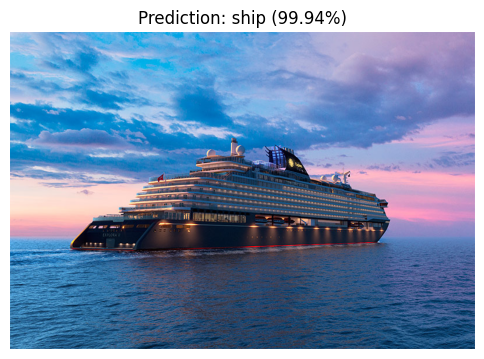

This image most likely belongs to ship with a 99.94% confidence.


In [12]:
# =====================================
# TRANSFER LEARNING (FINAL CLEAN VERSION + CLEAR IMAGE FIX)
# =====================================

!pip install -q tensorflow

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import zipfile
import os

print("TensorFlow version:", tf.__version__)

# =====================================
# MOUNT GOOGLE DRIVE
# =====================================
from google.colab import drive
drive.mount('/content/drive')

# =====================================
# EXTRACT ZIP
# =====================================
zip_path = '/content/drive/MyDrive/archive (5).zip'
extract_path = '/content/dataset'

import shutil
shutil.rmtree(extract_path, ignore_errors=True)
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully")

# =====================================
# PATH
# =====================================
train_dir = '/content/dataset/Dataset/train'

# =====================================
# LOAD DATASET
# =====================================
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("Classes:", class_names)

# Normalize
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# =====================================
# MODEL
# =====================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training...")
model.fit(train_dataset, validation_data=val_dataset, epochs=3)

print("✅ Training complete")

# =====================================
# TEST IMAGE (CLEAR DISPLAY FIX)
# =====================================
from google.colab import files

print("Upload test image (train.jpg)")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# 🔹 Load ORIGINAL image (for display)
img_original = image.load_img(img_path)

# 🔹 Load RESIZED image (for model)
img_resized = image.load_img(img_path, target_size=(160, 160))

img_array = image.img_to_array(img_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# 🔥 SHOW ORIGINAL CLEAR IMAGE
plt.figure(figsize=(6,6))
plt.imshow(img_original)
plt.axis('off')
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.show()

print(f"This image most likely belongs to {predicted_class} with a {confidence:.2f}% confidence.")